In [2]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
%pip install matplotlib
%pip install scikit-learn

Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import numpy as np
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader, ConcatDataset, random_split
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score
import json
from datetime import datetime

In [4]:
def prepare_clean_data(dataset_name='mnist', data_dir='./data'):
    """
    Pobiera zbiór MNIST lub Fashion-MNIST i przygotowuje go jako klasę bazową 'clean' (etykieta 0).
    Zwraca zbiór treningowy, testowy oraz surowe obrazy (do późniejszej modyfikacji).
    """
    print(f"Rozpoczynam pobieranie i ładowanie zbioru {dataset_name.upper()}...")
    
    transform = transforms.Compose([
        transforms.ToTensor()
    ])

    if dataset_name.lower() == 'mnist':
        dataset_class = datasets.MNIST
    elif dataset_name.lower() == 'fashion_mnist':
        dataset_class = datasets.FashionMNIST
    else:
        raise ValueError("Nieobsługiwany zbiór danych. Wybierz 'mnist' lub 'fashion_mnist'.")

    # Pobieranie danych
    original_train_data = dataset_class(root=data_dir, train=True, download=True, transform=transform)
    original_test_data = dataset_class(root=data_dir, train=False, download=True, transform=transform)

    # Ekstrakcja i normalizacja obrazów treningowych
    train_images = original_train_data.data.float() / 255.0
    train_images = train_images.unsqueeze(1)
    train_labels = torch.zeros(len(train_images), dtype=torch.long) # Etykieta 0 (clean)
    
    # Ekstrakcja i normalizacja obrazów testowych
    test_images = original_test_data.data.float() / 255.0
    test_images = test_images.unsqueeze(1)
    test_labels = torch.zeros(len(test_images), dtype=torch.long) # Etykieta 0 (clean)

    clean_train_dataset = TensorDataset(train_images, train_labels)
    clean_test_dataset = TensorDataset(test_images, test_labels)
    
    print(f"Załadowano {len(clean_train_dataset)} obrazów treningowych oraz {len(clean_test_dataset)} testowych.\n")
    return clean_train_dataset, clean_test_dataset, train_images, test_images

def add_gaussian_noise(images, mean=0.0, std=0.4):
    """Dodaje losowy szum Gaussa do obrazu i przycina wartości do [0, 1]."""
    noise = torch.randn_like(images) * std + mean
    noisy_images = images + noise
    return torch.clamp(noisy_images, 0.0, 1.0)

def generate_attack_a(images, std=0.4):
    """Tworzy zbiór zaszumionych obrazów i oznacza je jako 'attack_a' (etykieta 1)."""
    print(f"Generowanie attack_a (szum Gaussa, odchylenie={std})...")
    attack_images = add_gaussian_noise(images, std=std)
    attack_labels = torch.ones(len(attack_images), dtype=torch.long) # Etykieta 1 (attack)
    return TensorDataset(attack_images, attack_labels)

def visualize_samples(dataset, num_samples=5, title_prefix=""):
    """Wyświetla kilka próbek ze zbioru wraz z etykietami."""
    fig, axes = plt.subplots(1, num_samples, figsize=(10, 2))
    for i in range(num_samples):
        image, label = dataset[i]
        axes[i].imshow(image.squeeze(), cmap='gray')
        axes[i].set_title(f"{title_prefix}Label: {label.item()}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

--- KOMÓRKA 1: ZBIÓR MNIST ---
Rozpoczynam pobieranie i ładowanie zbioru MNIST...
Załadowano 60000 obrazów treningowych oraz 10000 testowych.

Generowanie attack_a (szum Gaussa, odchylenie=0.4)...
Generowanie attack_a (szum Gaussa, odchylenie=0.4)...


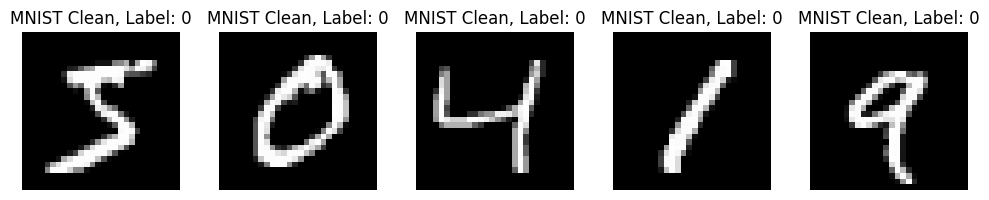

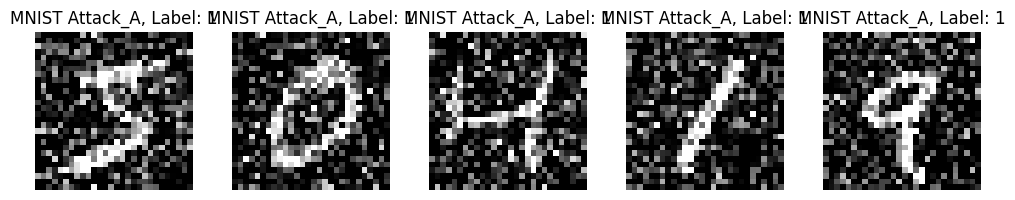

----------------------------------------



In [5]:
# %% [1] KOMÓRKA 1: Zbiór MNIST i Attack A (Szum Gaussa)
print("--- KOMÓRKA 1: ZBIÓR MNIST ---")
clean_train_mnist, clean_test_mnist, raw_train_imgs_mnist, raw_test_imgs_mnist = prepare_clean_data(dataset_name='mnist')

# Generowanie znanego ataku dla klasyfikatora (attack_a) dla MNIST
attack_a_train_mnist = generate_attack_a(raw_train_imgs_mnist, std=0.4)
attack_a_test_mnist = generate_attack_a(raw_test_imgs_mnist, std=0.4)

# Wizualizacja
visualize_samples(clean_train_mnist, title_prefix="MNIST Clean, ")
visualize_samples(attack_a_train_mnist, title_prefix="MNIST Attack_A, ")
print("-" * 40 + "\n")

--- KOMÓRKA 2: ZBIÓR FASHION-MNIST ---
Rozpoczynam pobieranie i ładowanie zbioru FASHION_MNIST...
Załadowano 60000 obrazów treningowych oraz 10000 testowych.



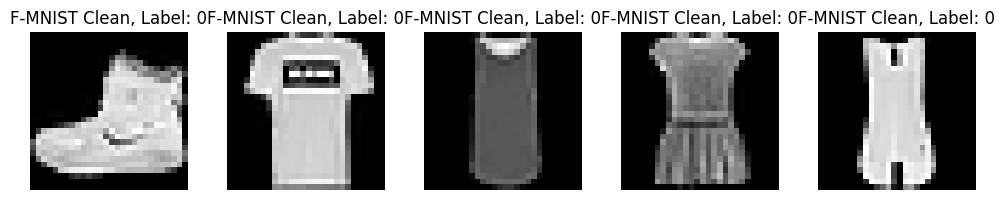

----------------------------------------



In [6]:
# %% [2] KOMÓRKA 2: Zbiór Fashion-MNIST
print("--- KOMÓRKA 2: ZBIÓR FASHION-MNIST ---")
clean_train_fmnist, clean_test_fmnist, raw_train_imgs_fmnist, raw_test_imgs_fmnist = prepare_clean_data(dataset_name='fashion_mnist')

# Wizualizacja bazowych danych Fashion-MNIST
visualize_samples(clean_train_fmnist, title_prefix="F-MNIST Clean, ")
print("-" * 40 + "\n")

--- KOMÓRKA 3: GENERACJA ATTACK_B (OOD) ---
Generowanie attack_b (Zastąpienie OOD - Out Of Distribution)...
Generowanie attack_b (Zastąpienie OOD - Out Of Distribution)...


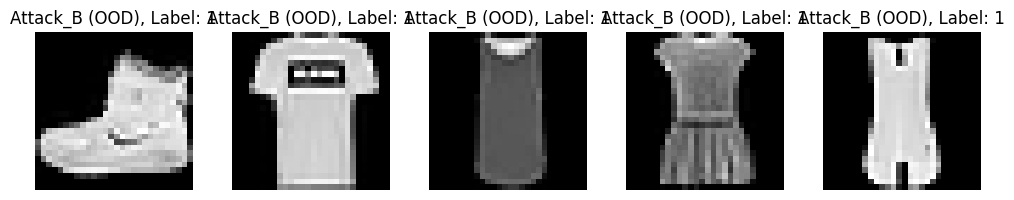


Gotowe! W tym momencie mamy 3 przygotowane zbiory do treningu i testowania:
1. Klasa 'clean' (MNIST) -> Etykiety 0
2. Klasa 'attack_a' (Zaszumiony MNIST) -> Etykiety 1 (Do treningu baseline'u)
3. Klasa 'attack_b' (OOD: Fashion-MNIST) -> Etykiety 1 (Zarezerwowany do testowania nieznanych ataków)


In [7]:
 # %% [3] KOMÓRKA 3: Generacja attack_b (Zastąpienie OOD, Atak nieznany)
print("--- KOMÓRKA 3: GENERACJA ATTACK_B (OOD) ---")
#"Zastąpienie OOD - jako atak użyj próbek z zupełnie innego zbioru"
# Używamy surowych obrazów Fashion-MNIST jako ataku (etykieta 1) wobec klasyfikatora uczonego na MNIST

def generate_attack_b_ood(ood_images):
    """Oznacza obrazy z innego zbioru (Out-Of-Distribution) jako attack_b (etykieta 1)."""
    print("Generowanie attack_b (Zastąpienie OOD - Out Of Distribution)...")
    attack_labels = torch.ones(len(ood_images), dtype=torch.long) # Etykieta 1 (attack)
    return TensorDataset(ood_images, attack_labels)

# Generowanie nieznanego ataku B (Fashion-MNIST jako atak na model MNIST)
attack_b_train = generate_attack_b_ood(raw_train_imgs_fmnist)
attack_b_test = generate_attack_b_ood(raw_test_imgs_fmnist)

# Wizualizacja ostatecznego ataku_b
visualize_samples(attack_b_train, title_prefix="Attack_B (OOD), ")

print("\nGotowe! W tym momencie mamy 3 przygotowane zbiory do treningu i testowania:")
print("1. Klasa 'clean' (MNIST) -> Etykiety 0")
print("2. Klasa 'attack_a' (Zaszumiony MNIST) -> Etykiety 1 (Do treningu baseline'u)")
print("3. Klasa 'attack_b' (OOD: Fashion-MNIST) -> Etykiety 1 (Zarezerwowany do testowania nieznanych ataków)")

In [8]:
# %% [4] KOMÓRKA 4: Podział na zbiory (Train, Val, Test_A, Test_B)
print("--- KOMÓRKA 4: PODZIAŁ NA ZBIORY ---")

# 1. Zbiór Treningowy i Walidacyjny
# Łączymy próbki clean i attack_a (oba mają po 60,000 próbek, co daje idealny balans 50/50)
combined_train_val = ConcatDataset([clean_train_mnist, attack_a_train_mnist])

# Dzielimy połączony zbiór na część treningową (80%) i walidacyjną (20%)
train_size = int(0.8 * len(combined_train_val))
val_size = len(combined_train_val) - train_size

train_dataset, val_dataset = random_split(combined_train_val, [train_size, val_size])
print(f"Zbiór Treningowy (Train): {len(train_dataset)} próbek (mieszanka Clean i Attack_A)")
print(f"Zbiór Walidacyjny (Val): {len(val_dataset)} próbek (mieszanka Clean i Attack_A)\n")

# 2. Zbiór Testowy 1 (Test_A - znane ataki)
# Wykorzystujemy dedykowane próbki testowe, których model nie widział w trakcie uczenia
test_a_dataset = ConcatDataset([clean_test_mnist, attack_a_test_mnist])
print(f"Zbiór Testowy 1 (Test_A): {len(test_a_dataset)} próbek (Clean i znany Attack_A)")

# 3. Zbiór Testowy 2 (Test_B - nieznane ataki OOD)
# Łączymy niewidziane próbki clean (z MNIST) z wygenerowanym attack_b (z Fashion-MNIST)
test_b_dataset = ConcatDataset([clean_test_mnist, attack_b_test])
print(f"Zbiór Testowy 2 (Test_B): {len(test_b_dataset)} próbek (Clean i nieznany Attack_B)")

print("\nWszystkie zbiory bazowe są gotowe!\n")

--- KOMÓRKA 4: PODZIAŁ NA ZBIORY ---
Zbiór Treningowy (Train): 96000 próbek (mieszanka Clean i Attack_A)
Zbiór Walidacyjny (Val): 24000 próbek (mieszanka Clean i Attack_A)

Zbiór Testowy 1 (Test_A): 20000 próbek (Clean i znany Attack_A)
Zbiór Testowy 2 (Test_B): 20000 próbek (Clean i nieznany Attack_B)

Wszystkie zbiory bazowe są gotowe!



In [9]:
def load_pythia_data(data_dir='./pythia', partition='clean'):
    """
    Faza 2: Ładuje dane obrazkowe ze zbioru ukrytego Pythia (obrazy 70x70 px z plików PNG).
    Oznacza partycję 'clean' jako 0, a każdą inną ('attack_*') jako 1.
    """
    folder_path = os.path.join(data_dir, partition)
    
    if not os.path.exists(folder_path) or not os.path.isdir(folder_path):
        print(f"  [OSTRZEŻENIE] Brak folderu: {folder_path}")
        print("  Generuję tymczasową zaślepkę 1000 próbek (szum), aby zapobiec błędom kompilacji.")
        raw_data = np.random.rand(1000, 70, 70).astype(np.float32)
        images = torch.tensor(raw_data, dtype=torch.float32).unsqueeze(1)
        label_val = 0 if partition == 'clean' else 1
        labels = torch.full((1000,), label_val, dtype=torch.long)
        return TensorDataset(images, labels)
        
    print(f"  Ładowanie obrazów z folderu: {folder_path}...")
    image_tensors = []
    
    # Pobieramy i sortujemy nazwy plików (np. 0.png, 1.png ...)
    file_names = sorted([f for f in os.listdir(folder_path) if f.endswith('.png')])
    
    # Transformacja ładująca obraz z formatu PIL do tensora PyTorch [0.0 - 1.0]
    transform = transforms.ToTensor()
    
    for file_name in file_names:
        img_path = os.path.join(folder_path, file_name)
        # Wczytujemy obraz wymuszając skalę szarości ('L')
        img = Image.open(img_path).convert('L')
        img_tensor = transform(img) # Wynik: kształt (1, 70, 70)
        image_tensors.append(img_tensor)
        
    # Łączymy listę (1000 elementów) w jeden duży tensor o wymiarach (1000, 1, 70, 70)
    images = torch.stack(image_tensors)
    
    # Ustalanie etykiet
    label_val = 0 if partition == 'clean' else 1
    labels = torch.full((len(images),), label_val, dtype=torch.long)
    
    return TensorDataset(images, labels)

def visualize_samples(dataset, num_samples=5, title_prefix=""):
    """Wyświetla kilka próbek ze zbioru wraz z etykietami."""
    fig, axes = plt.subplots(1, num_samples, figsize=(10, 2))
    for i in range(num_samples):
        image, label = dataset[i]
        axes[i].imshow(image.squeeze(), cmap='gray')
        axes[i].set_title(f"{title_prefix}Label: {label.item()}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

--- KOMÓRKA 5: FAZA 2 - ZBIÓR UKRYTY PYTHIA ---
Ładowanie danych obrazkowych Pythia z folderów...
  Ładowanie obrazów z folderu: ./pythia\clean...
  [OSTRZEŻENIE] Brak folderu: ./pythia\attack_1
  Generuję tymczasową zaślepkę 1000 próbek (szum), aby zapobiec błędom kompilacji.
  [OSTRZEŻENIE] Brak folderu: ./pythia\attack_2
  Generuję tymczasową zaślepkę 1000 próbek (szum), aby zapobiec błędom kompilacji.

Podsumowanie etykietowania (Pythia):
 - Załadowano Pythia 'clean': 1000 próbek (Etykieta 0).
 - Załadowano Pythia 'attack_a' (partycja attack_1): 1000 próbek (Etykieta 1).
 - Załadowano Pythia 'attack_b' (partycja attack_2): 1000 próbek (Etykieta 1).

Wizualizacja próbek Pythia (rozdzielczość 70x70 px):


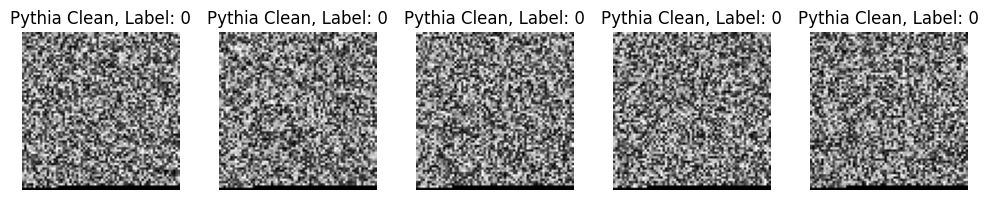

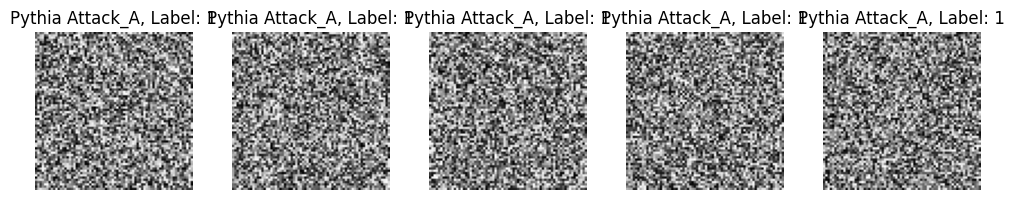

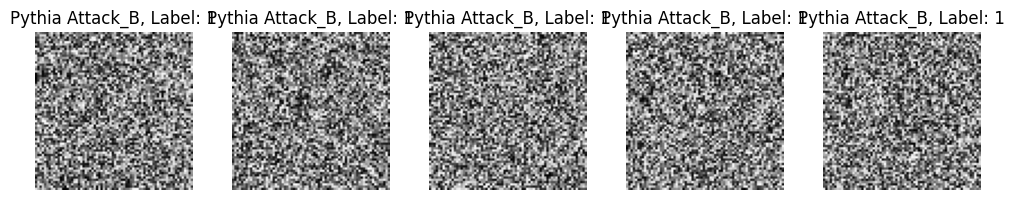

In [10]:
# %% [5] KOMÓRKA 5: Faza 2 - Zbiór Ukryty Pythia (Eksploracja i etykietowanie)
print("--- KOMÓRKA 5: FAZA 2 - ZBIÓR UKRYTY PYTHIA ---")
print("Ładowanie danych obrazkowych Pythia z folderów...")

# 1. Odszukaj podzbiór oznaczony jako clean i nadaj mu etykietę 0.
pythia_clean = load_pythia_data(data_dir='./pythia', partition='clean')

# 2. Wybierz dowolny z 8 dostępnych ataków (np. folder "1" lub "attack_1") jako attack_a (etykieta 1).
# UWAGA: Jeśli foldery po rozpakowaniu nazywają się po prostu '1', zmień wartość partition='1'
pythia_attack_a = load_pythia_data(data_dir='./pythia', partition='attack_1')

# 3. Wybierz inny dowolny atak jako attack_b (etykieta 1 - na potrzeby ewaluacji).
pythia_attack_b = load_pythia_data(data_dir='./pythia', partition='attack_2')

print(f"\nPodsumowanie etykietowania (Pythia):")
print(f" - Załadowano Pythia 'clean': {len(pythia_clean)} próbek (Etykieta 0).")
print(f" - Załadowano Pythia 'attack_a' (partycja attack_1): {len(pythia_attack_a)} próbek (Etykieta 1).")
print(f" - Załadowano Pythia 'attack_b' (partycja attack_2): {len(pythia_attack_b)} próbek (Etykieta 1).\n")

print("Wizualizacja próbek Pythia (rozdzielczość 70x70 px):")
visualize_samples(pythia_clean, title_prefix="Pythia Clean, ")
visualize_samples(pythia_attack_a, title_prefix="Pythia Attack_A, ")
visualize_samples(pythia_attack_b, title_prefix="Pythia Attack_B, ")

In [11]:
# %% [6] KOMÓRKA 6: Faza 2 - Podział na zbiory i Preprocessing (Pythia)
print("--- KOMÓRKA 6: FAZA 2 - PODZIAŁ I PREPROCESSING (PYTHIA) ---")

# 1. Preprocessing (Normalizacja)
# Zgodnie z wymogiem, wartości 0-255 muszą być znormalizowane do 0.0-1.0.
# Jest to już zrealizowane w funkcji `load_pythia_data` dzięki wywołaniu `transforms.ToTensor()`,
# które dla formatu obrazu (PIL) automatycznie dzieli wartości pikseli przez 255.0.
print("Preprocessing: Obrazy są znormalizowane do przedziału [0.0, 1.0] (zapewnione przez transforms.ToTensor()).")

# 2. Ręczny podział na zbiory bazowe
# W przeciwieństwie do MNIST, zbiór Pythia nie jest fabrycznie podzielony na train i test.
# Zrobimy to sami, odkładając 20% z każdego zbioru jako twardy zbiór testowy.
def split_train_test(dataset, train_ratio=0.8):
    train_len = int(len(dataset) * train_ratio)
    test_len = len(dataset) - train_len
    return random_split(dataset, [train_len, test_len])

pythia_clean_train_base, pythia_clean_test = split_train_test(pythia_clean)
pythia_atk_a_train_base, pythia_atk_a_test = split_train_test(pythia_attack_a)

# Cały attack_b zostawiamy do testowania (nie potrzebujemy go w treningu)
pythia_atk_b_test = pythia_attack_b

# 3. Zbiór Treningowy i Walidacyjny
pythia_combined_train_val = ConcatDataset([pythia_clean_train_base, pythia_atk_a_train_base])

pythia_train_size = int(0.8 * len(pythia_combined_train_val))
pythia_val_size = len(pythia_combined_train_val) - pythia_train_size

pythia_train_dataset, pythia_val_dataset = random_split(pythia_combined_train_val, [pythia_train_size, pythia_val_size])

print(f"\nPodział dokonany!")
print(f"Zbiór Treningowy Pythia (Train): {len(pythia_train_dataset)} próbek (mieszanka Clean i Attack_A)")
print(f"Zbiór Walidacyjny Pythia (Val): {len(pythia_val_dataset)} próbek (mieszanka Clean i Attack_A)")

# 4. Zbiór Testowy 1 i 2
pythia_test_a_dataset = ConcatDataset([pythia_clean_test, pythia_atk_a_test])
pythia_test_b_dataset = ConcatDataset([pythia_clean_test, pythia_atk_b_test])

print(f"Zbiór Testowy 1 Pythia (Test_A): {len(pythia_test_a_dataset)} próbek (Clean i znany Attack_A)")
print(f"Zbiór Testowy 2 Pythia (Test_B): {len(pythia_test_b_dataset)} próbek (Clean i nieznany Attack_B)")
print("\nGotowe! Zbiór ukryty Pythia jest w pełni przygotowany do trenowania modelu.")

--- KOMÓRKA 6: FAZA 2 - PODZIAŁ I PREPROCESSING (PYTHIA) ---
Preprocessing: Obrazy są znormalizowane do przedziału [0.0, 1.0] (zapewnione przez transforms.ToTensor()).

Podział dokonany!
Zbiór Treningowy Pythia (Train): 1280 próbek (mieszanka Clean i Attack_A)
Zbiór Walidacyjny Pythia (Val): 320 próbek (mieszanka Clean i Attack_A)
Zbiór Testowy 1 Pythia (Test_A): 400 próbek (Clean i znany Attack_A)
Zbiór Testowy 2 Pythia (Test_B): 1200 próbek (Clean i nieznany Attack_B)

Gotowe! Zbiór ukryty Pythia jest w pełni przygotowany do trenowania modelu.


In [12]:
class AnomalyCNN(nn.Module):
    """
    Sieć konwolucyjna (CNN) do detekcji anomalii.
    Zaprojektowana z elastycznym wymiarem wejścia (obsługuje 28x28 i 70x70).
    """
    def __init__(self, input_size=28):
        super(AnomalyCNN, self).__init__()
        
        # --- 1. Warstwy konwolucyjne ---
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # Warstwa łącząca zmniejszająca rozdzielczość o połowę
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # --- 2. Dynamiczne obliczanie wymiaru po Flatten ---
        self.flatten_size = self._get_flatten_size(input_size)
        
        # --- 3. Warstwy Gęste (Dense) ---
        self.fc1 = nn.Linear(self.flatten_size, 128)
        # Warstwa wyjściowa: 1 neuron dla klasyfikacji binarnej
        self.fc2 = nn.Linear(128, 1)

    def _get_flatten_size(self, input_size):
        """
        Przepuszcza "pusty" tensor przez sieć, aby określić wymiar potrzebny 
        dla pierwszej warstwy gęstej (Linear). Eliminuje to konieczność
        ręcznego wyliczania tensorów dla rozmiarów 28x28 oraz 70x70.
        """
        dummy_tensor = torch.zeros(1, 1, input_size, input_size)
        x = self.pool(F.relu(self.conv1(dummy_tensor)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        return x.numel() # Zwraca całkowitą liczbę elementów (flatten size)

    def forward(self, x):
        # Przejście przez warstwy konwolucyjne i relu
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        # Spłaszczenie (Flatten)
        x = x.view(-1, self.flatten_size)
        
        # Przejście przez warstwy gęste
        x = F.relu(self.fc1(x))
        # Zastosowanie aktywacji Sigmoid do uzyskania prawdopodobieństwa (0.0 do 1.0)
        x = torch.sigmoid(self.fc2(x))
        
        return x

In [13]:
# %% [7] KOMÓRKA 7: Faza 3 - Projektowanie Architektury Modelu i Konfiguracja
print("--- KOMÓRKA 7: FAZA 3 - ARCHITEKTURA MODELU (CNN) ---")

# 1. Inicjalizacja modeli z automatycznym dopasowaniem do rozmiaru obrazu
print("Inicjalizacja modelu dla MNIST (wejście 28x28)...")
model_mnist = AnomalyCNN(input_size=28)
print(model_mnist) # Wyświetli podsumowanie warstw

print("\nInicjalizacja modelu dla Pythia (wejście 70x70)...")
model_pythia = AnomalyCNN(input_size=70)

# 2. Konfiguracja uczenia
# Jako że użyliśmy na końcu warstwy Sigmoid i robimy klasyfikację binarną, używamy Binary Cross Entropy Loss
criterion = nn.BCELoss()

# Inicjalizacja optymalizatorów dla obu modeli
optimizer_mnist = optim.Adam(model_mnist.parameters(), lr=0.001)
optimizer_pythia = optim.Adam(model_pythia.parameters(), lr=0.001)

print("\nKonfiguracja modelu zakończona sukcesem!")
print(" - Architektura: 3x Conv2d + MaxPooling -> Flatten -> 2x Dense (Sigmoid)")
print(" - Funkcja straty: Binary Crossentropy (BCELoss)")
print(" - Optymalizator: Adam (Learning Rate = 0.001)")
print(" - Zaimportowano metryki sklearn gotowe do pętli uczenia: Accuracy, Precision, Recall, AUC-ROC")

--- KOMÓRKA 7: FAZA 3 - ARCHITEKTURA MODELU (CNN) ---
Inicjalizacja modelu dla MNIST (wejście 28x28)...
AnomalyCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=576, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

Inicjalizacja modelu dla Pythia (wejście 70x70)...

Konfiguracja modelu zakończona sukcesem!
 - Architektura: 3x Conv2d + MaxPooling -> Flatten -> 2x Dense (Sigmoid)
 - Funkcja straty: Binary Crossentropy (BCELoss)
 - Optymalizator: Adam (Learning Rate = 0.001)
 - Zaimportowano metryki sklearn gotowe do pętli uczenia: Accuracy, Precision, Recall, AUC-ROC


In [14]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=20, patience=3):
    """
    Trenuje model z uwzględnieniem zbioru walidacyjnego oraz mechanizmu Early Stopping.
    Zwraca wytrenowany model (z przywróconymi najlepszymi wagami).
    """
    # Zapiszemy tu najlepszy stan sieci, by zapobiec overfitingowi
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    # Opcjonalnie: przeniesienie obliczeń na GPU (jeśli jest zainstalowane/dostępne)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    for epoch in range(num_epochs):
        # --- FAZA TRENINGU ---
        model.train() # Ustawiamy sieć w tryb uczenia
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            # BCELoss wymaga, aby etykiety były typu float i miały kształt zgodny z wyjściem sieci [batch_size, 1]
            labels = labels.to(device).view(-1, 1).float()
            
            optimizer.zero_grad() # Wyzerowanie poprzednich gradientów
            
            outputs = model(inputs) # "Zgadnięcie" sieci
            loss = criterion(outputs, labels) # Obliczenie błędu (straty)
            
            loss.backward() # Propagacja wsteczna
            optimizer.step() # Aktualizacja wag sieci
            
            running_loss += loss.item() * inputs.size(0)
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        
        # --- FAZA WALIDACJI ---
        model.eval() # Ustawiamy sieć w tryb ewaluacji (wyłącza np. Dropout, jeśli byłby użyty)
        val_loss = 0.0
        
        with torch.no_grad(): # Zatrzymujemy śledzenie gradientów (oszczędza pamięć)
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device).view(-1, 1).float()
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
        epoch_val_loss = val_loss / len(val_loader.dataset)
        
        print(f'Epoka {epoch+1:02d}/{num_epochs:02d} | Strata (Train): {epoch_train_loss:.4f} | Strata (Val): {epoch_val_loss:.4f}')
        
        # --- EARLY STOPPING ---
        # Sprawdzamy, czy strata na zbiorze walidacyjnym jest mniejsza niż dotychczas najlepsza
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            # Kopiujemy i zabezpieczamy wagi sieci z tej epoki
            best_model_wts = copy.deepcopy(model.state_dict()) 
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f" -> Early Stopping! Brak poprawy od {patience} epok. Przerywam trening.")
                break
                
    print(f"Najlepsza strata walidacyjna (Val Loss): {best_val_loss:.4f}")
    
    # Przywrócenie najlepszych wag (tych sprzed overfittingu) do modelu
    model.load_state_dict(best_model_wts)
    return model

In [15]:
# %% [8] KOMÓRKA 8: Faza 4 - Trenowanie Modelu (Baseline)
print("\n--- KOMÓRKA 8: FAZA 4 - TRENOWANIE MODELU (BASELINE) ---")

# 1. Przygotowanie DataLoaderów
# DataLoader tnie nam gigantyczne zbiory danych na mniejsze paczki (tzw. batche) po 64 próbki
batch_size = 64

print("Tworzenie DataLoaderów dla danych referencyjnych (MNIST)...")
# Zbiory te zostały utworzone z clean i attack_a (nie widziały attack_b)
train_loader_mnist = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader_mnist = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print("Tworzenie DataLoaderów dla danych ukrytych (Pythia)...")
train_loader_pythia = DataLoader(pythia_train_dataset, batch_size=batch_size, shuffle=True)
val_loader_pythia = DataLoader(pythia_val_dataset, batch_size=batch_size, shuffle=False)

# 2. Trening Baseline dla MNIST
print("\n>>> ROZPOCZĘCIE TRENINGU: ZBIÓR MNIST (Clean + Attack_A) <<<")
model_mnist = train_model(
    model=model_mnist, 
    train_loader=train_loader_mnist, 
    val_loader=val_loader_mnist, 
    criterion=criterion, 
    optimizer=optimizer_mnist, 
    num_epochs=15, 
    patience=3 # Przerwie, jeśli przez 3 epoki model przestanie się uczyć
)

# 3. Trening Baseline dla Pythia
print("\n>>> ROZPOCZĘCIE TRENINGU: ZBIÓR PYTHIA (Clean + Attack_A) <<<")
model_pythia = train_model(
    model=model_pythia, 
    train_loader=train_loader_pythia, 
    val_loader=val_loader_pythia, 
    criterion=criterion, 
    optimizer=optimizer_pythia, 
    num_epochs=15, 
    patience=3
)

print("\nGratulacje! Faza 4 zakończona.")
print("Obydwa modele bazowe (Baseline) zostały wytrenowane wyłącznie z użyciem znanego ataku_a!")


--- KOMÓRKA 8: FAZA 4 - TRENOWANIE MODELU (BASELINE) ---
Tworzenie DataLoaderów dla danych referencyjnych (MNIST)...
Tworzenie DataLoaderów dla danych ukrytych (Pythia)...

>>> ROZPOCZĘCIE TRENINGU: ZBIÓR MNIST (Clean + Attack_A) <<<
Epoka 01/15 | Strata (Train): 0.0088 | Strata (Val): 0.0000
Epoka 02/15 | Strata (Train): 0.0000 | Strata (Val): 0.0000
Epoka 03/15 | Strata (Train): 0.0000 | Strata (Val): 0.0000
Epoka 04/15 | Strata (Train): 0.0000 | Strata (Val): 0.0000
Epoka 05/15 | Strata (Train): 0.0000 | Strata (Val): 0.0000
Epoka 06/15 | Strata (Train): 0.0000 | Strata (Val): 0.0000
Epoka 07/15 | Strata (Train): 0.0000 | Strata (Val): 0.0000
Epoka 08/15 | Strata (Train): 0.0000 | Strata (Val): 0.0000
Epoka 09/15 | Strata (Train): 0.0000 | Strata (Val): 0.0000
Epoka 10/15 | Strata (Train): 0.0000 | Strata (Val): 0.0000
Epoka 11/15 | Strata (Train): 0.0000 | Strata (Val): 0.0000
Epoka 12/15 | Strata (Train): 0.0000 | Strata (Val): 0.0000
Epoka 13/15 | Strata (Train): 0.0000 | Strata

In [16]:
# ==========================================
# FAZA 5: FUNKCJA EWALUACYJNA
# ==========================================

def evaluate_model(model, test_loader, threshold=0.5):
    """
    Przeprowadza ewaluację modelu na podanym zbiorze testowym.
    Oblicza i wypisuje metryki: Accuracy, Precision, Recall, F1-Score, AUC-ROC.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval() # Przestawienie sieci w tryb ewaluacji (wyłączenie treningu)
    
    all_labels = []
    all_preds_probs = []
    
    with torch.no_grad(): # Zablokowanie obliczania gradientów
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float()
            
            outputs = model(inputs).squeeze() # Pobranie prawdopodobieństw z sieci
            
            # Zabezpieczenie w razie paczki o wielkości dokładnie 1 (batch_size=1)
            if outputs.dim() == 0:
                outputs = outputs.unsqueeze(0)
                
            all_preds_probs.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # Konwersja do tablic NumPy dla biblioteki scikit-learn
    all_labels = np.array(all_labels)
    all_preds_probs = np.array(all_preds_probs)
    # Prawdopodobieństwo >= 0.5 uznajemy za klasę 1 (anomalia)
    all_preds_classes = (all_preds_probs >= threshold).astype(int)
    
    # Obliczanie metryk
    from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score
    acc = accuracy_score(all_labels, all_preds_classes)
    prec = precision_score(all_labels, all_preds_classes, zero_division=0)
    rec = recall_score(all_labels, all_preds_classes, zero_division=0)
    f1 = f1_score(all_labels, all_preds_classes, zero_division=0)
    
    try:
        auc = roc_auc_score(all_labels, all_preds_probs)
    except ValueError:
        # Może wystąpić, gdy zbiór testowy w batchu ma tylko jedną klasę
        auc = float('nan')
        
    print(f"  Accuracy:  {acc:.4f} (Dokładność ogólna)")
    print(f"  Precision: {prec:.4f} (Jak często wytypowana anomalia faktycznie nią była)")
    print(f"  Recall:    {rec:.4f} (Jaką część wszystkich prawdziwych anomalii udało się wykryć)")
    print(f"  F1-Score:  {f1:.4f} (Średnia harmoniczna precyzji i czułości)")
    print(f"  AUC-ROC:   {auc:.4f} (Zdolność modelu do rozróżniania klas)")
    
    # TUTAJ JEST KLUCZOWA ZMIANA - funkcja zwraca teraz 5 elementów, w tym f1:
    return acc, prec, rec, f1, auc

In [17]:
 # %% [9] KOMÓRKA 9: Faza 5 - Ewaluacja i Sprawdzenie Skuteczności (Test_A)
print("\n--- KOMÓRKA 9: FAZA 5 - EWALUACJA NA ZNANYM ATAKU (TEST_A) ---")

print("Przygotowanie DataLoaderów testowych (Test_A)...")
# Ładujemy zbiory, które składają się z Czystych obrazów i Znanych rodzajów ataku
test_a_loader_mnist = DataLoader(test_a_dataset, batch_size=batch_size, shuffle=False)
test_a_loader_pythia = DataLoader(pythia_test_a_dataset, batch_size=batch_size, shuffle=False)

print("\n>>> EWALUACJA MNIST (Test_A: Clean + Attack_A) <<<")
res_mnist_a = evaluate_model(model_mnist, test_a_loader_mnist)

print("\n>>> EWALUACJA PYTHIA (Test_A: Clean + Attack_A) <<<")
res_pythia_a = evaluate_model(model_pythia, test_a_loader_pythia)

print("\n[WNIOSEK KROKU 1]: Jeśli metryki są bardzo wysokie (np. blisko 1.0/100%),")
print("oznacza to, że nasz bazowy model skutecznie nauczył się rozpoznawać ataki,")
print("które demonstrowaliśmy mu podczas sesji treningowej.")



--- KOMÓRKA 9: FAZA 5 - EWALUACJA NA ZNANYM ATAKU (TEST_A) ---
Przygotowanie DataLoaderów testowych (Test_A)...

>>> EWALUACJA MNIST (Test_A: Clean + Attack_A) <<<
  Accuracy:  1.0000 (Dokładność ogólna)
  Precision: 1.0000 (Jak często wytypowana anomalia faktycznie nią była)
  Recall:    1.0000 (Jaką część wszystkich prawdziwych anomalii udało się wykryć)
  F1-Score:  1.0000 (Średnia harmoniczna precyzji i czułości)
  AUC-ROC:   1.0000 (Zdolność modelu do rozróżniania klas)

>>> EWALUACJA PYTHIA (Test_A: Clean + Attack_A) <<<
  Accuracy:  1.0000 (Dokładność ogólna)
  Precision: 1.0000 (Jak często wytypowana anomalia faktycznie nią była)
  Recall:    1.0000 (Jaką część wszystkich prawdziwych anomalii udało się wykryć)
  F1-Score:  1.0000 (Średnia harmoniczna precyzji i czułości)
  AUC-ROC:   1.0000 (Zdolność modelu do rozróżniania klas)

[WNIOSEK KROKU 1]: Jeśli metryki są bardzo wysokie (np. blisko 1.0/100%),
oznacza to, że nasz bazowy model skutecznie nauczył się rozpoznawać ataki,


In [18]:
 # %% [10] KOMÓRKA 10: Faza 5 - Właściwy eksperyment (Test_B - Atak nieznany)
print("\n--- KOMÓRKA 10: FAZA 5 - EWALUACJA NA NIEZNANYM ATAKU (TEST_B) ---")

print("Przygotowanie DataLoaderów testowych (Test_B)...")
# Ładujemy zbiory, które składają się z Czystych obrazów oraz NIEZNANYCH rodzajów ataku B
test_b_loader_mnist = DataLoader(test_b_dataset, batch_size=batch_size, shuffle=False)
test_b_loader_pythia = DataLoader(pythia_test_b_dataset, batch_size=batch_size, shuffle=False)

print("\n>>> EWALUACJA MNIST (Test_B: Clean + Attack_B / OOD) <<<")
res_mnist_b = evaluate_model(model_mnist, test_b_loader_mnist)

print("\n>>> EWALUACJA PYTHIA (Test_B: Clean + Attack_B) <<<")
res_pythia_b = evaluate_model(model_pythia, test_b_loader_pythia)

print("\n[ANALIZA KROKU 2 - DRZĘSĄCY SPADEK SKUTECZNOŚCI]:")
print("Zapewne zauważyłeś przed chwilą drastyczny spadek skuteczności (szczególnie Recall, F1 i AUC)")
print("na zbiorze Test_B w porównaniu do wyników ze zbioru Test_A.")
print("Dlaczego tak się dzieje? ")
print("Klasyfikator nadzorowany nauczył się w Fazie 4 specyficznych cech Ataku A (np. szumu lub określonego wzoru z Pythia).")
print("Nie zbudował jednak pojęcia 'czym jest obraz normalny'. Kiedy więc zobaczył Atak B, zignorował go ")
print("lub uznał za klasyfikację 'czystą' (0), bo nie pasował do wyuczonego przez niego wzorca błędu.")


--- KOMÓRKA 10: FAZA 5 - EWALUACJA NA NIEZNANYM ATAKU (TEST_B) ---
Przygotowanie DataLoaderów testowych (Test_B)...

>>> EWALUACJA MNIST (Test_B: Clean + Attack_B / OOD) <<<
  Accuracy:  0.6033 (Dokładność ogólna)
  Precision: 1.0000 (Jak często wytypowana anomalia faktycznie nią była)
  Recall:    0.2066 (Jaką część wszystkich prawdziwych anomalii udało się wykryć)
  F1-Score:  0.3424 (Średnia harmoniczna precyzji i czułości)
  AUC-ROC:   0.9989 (Zdolność modelu do rozróżniania klas)

>>> EWALUACJA PYTHIA (Test_B: Clean + Attack_B) <<<
  Accuracy:  1.0000 (Dokładność ogólna)
  Precision: 1.0000 (Jak często wytypowana anomalia faktycznie nią była)
  Recall:    1.0000 (Jaką część wszystkich prawdziwych anomalii udało się wykryć)
  F1-Score:  1.0000 (Średnia harmoniczna precyzji i czułości)
  AUC-ROC:   1.0000 (Zdolność modelu do rozróżniania klas)

[ANALIZA KROKU 2 - DRZĘSĄCY SPADEK SKUTECZNOŚCI]:
Zapewne zauważyłeś przed chwilą drastyczny spadek skuteczności (szczególnie Recall, F1 i 

In [19]:
# %% [11] KOMÓRKA 11: Faza 6 - Zapis wyników i wnioski końcowe
print("\n--- KOMÓRKA 11: FAZA 6 - ZAPIS WYNIKÓW I WNIOSKI ---")
import json
from datetime import datetime

# Pomocnicza funkcja do bezpiecznego parsowania wyników
def parse_results(res):
    if len(res) == 5:
        return {"Accuracy": res[0], "Precision": res[1], "Recall": res[2], "F1_Score": res[3], "AUC_ROC": res[4]}
    else:
        return {"Accuracy": res[0], "Precision": res[1], "Recall": res[2], "F1_Score": "Brak danych", "AUC_ROC": res[3]}

# 1. Zebranie wyników w czytelną strukturę słownika
results_summary = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "MNIST_Experiment": {
        "Test_A_Znany_Atak": parse_results(res_mnist_a),
        "Test_B_Nieznany_Atak": parse_results(res_mnist_b)
    },
    "PYTHIA_Experiment": {
        "Test_A_Znany_Atak": parse_results(res_pythia_a),
        "Test_B_Nieznany_Atak": parse_results(res_pythia_b)
    }
}

# 2. Zapis wyników do pliku JSON
output_filename = "faza1_wyniki_eksperymentu.json"
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(results_summary, f, indent=4, ensure_ascii=False)
    
print(f"Pomyślnie zapisano szczegółowe wyniki z obu eksperymentów do pliku: {output_filename}")


--- KOMÓRKA 11: FAZA 6 - ZAPIS WYNIKÓW I WNIOSKI ---
Pomyślnie zapisano szczegółowe wyniki z obu eksperymentów do pliku: faza1_wyniki_eksperymentu.json


Zwykła Sieć Konwolucyjna trenowana na jednej grupie ataków, doskonale
wykrywa tę grupę (Test A). Ponosi jednak klęskę przy próbie wykrycia nowych form modyfikacji (Test B).


Oznacza to, że nasz model nie zbudował umiejętności detekcji anomalii, 
lecz jedynie 'nauczył się na pamięć' konkretnego defektu (np. szumu).

Dlatego będzie trzeba wykonać krok 2. Naucz model na An - różnych klasach ataków. Sprawdź, czy
zwiększenie różnorodności danych treningowych poprawia wykrywalność nowego ataku An+1.